# 🏥 Laboratory Data Quality Assessment & Exploratory Analysis

**Analyst:** Sepideh Ziaei Chamgordani  
**Date:** September 6, 2026  
**Project Type:** Exploratory Data Analysis (EDA) — Synthetic Patient Laboratory Data

---

## 📑 Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Introduction & Project Scope](#1-introduction) | Background, objectives, and scope |
| 2 | [Libraries](#2-libraries) | Python packages used |
| 3 | [Data Loading & Initial Inspection](#3-data-loading) | Structure, types, first look |
| 4 | [Data Quality Assessment & Cleaning](#4-data-quality) | Missing values, duplicates, outliers |
| 5 | [Descriptive Analysis](#5-descriptive-analysis) | Summary statistics, group comparisons |
| 6 | [Exploratory Visualization](#6-visualizations) | Distributions, relationships, correlations |
| 7 | [Findings & Conclusions](#7-findings) | Key insights for the client |
| 8 | [Limitations](#8-limitations) | Caveats and boundaries of this analysis |

In [ ]:
## 1. Introduction <a id="1-introduction"></a>

### Background
This notebook contains an exploratory data analysis (EDA) performed on a dataset of 500 synthetic patient-level laboratory records.

### Objectives
This analysis addresses three goals:
1. **Clean and validate** the data — identify missing values, duplicates, and implausible readings.
2. **Summarize** key variables — describe central tendencies and spread of laboratory measurements.
3. **Explore visually** — reveal relationships between measurements (e.g., BMI vs. Glucose, Triglycerides vs. HDL) and differences between demographic groups.

### Scope & Disclaimer
> ⚠️ This is a **strictly exploratory analysis**. No predictive models are built, and no clinical diagnoses or causal claims are made. The goal is to produce a clean dataset and a clear, reproducible summary that a non-technical stakeholder can understand.

### Dataset at a Glance
- **Source:** Synthetic patient-level laboratory records (AI-generated for portfolio purposes)
- **Size:** 503 records × 13 variables → 500 records after cleaning
- **Features:** Demographics (`Age`, `Sex`, `BMI`), lab measurements (glucose, HbA1c, lipid panel, blood pressure), and a binary target (`Diabetes`)

In [1]:
## 2. Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dataframe_image as dfi
import seaborn as sns
from IPython.display import display

In [2]:
## 3. Data Loading and Initial Inspection

patients_df = pd.read_excel (r'C:\Users\Sepideh\OneDrive\Desktop\p1\laboratory_patient_data_raw.xlsx')

print("Dataset shape:", patients_df.shape)

Dataset shape: (503, 13)


In [3]:
## 3.1 Preview of Raw Data

patients_df.head()

,Patient_ID,Age,Sex,BMI,Glucose_mg_dL,HbA1c_percent,Total_Cholesterol_mg_dL,LDL_mg_dL,HDL_mg_dL,Triglycerides_mg_dL,Systolic_BP_mmHg,Diastolic_BP_mmHg,Diabetes
0,LAB-0178,63,M,NaN,105.5,6.32,181.9,81.1,61.9,100.7,140.4,72.2,No
1,LAB-0398,72,Male,24.2,96.6,5.59,177.7,90.1,66.2,196.6,141.3,92.9,No
2,LAB-0410,69,Female,22.7,109.9,4.75,208.8,120.7,63.1,90.6,141.8,71.2,Yes
3,LAB-0004,25,Female,27.7,94.9,5.11,188.7,103.5,52.6,148.0,122.4,70.8,No
4,LAB-0295,49,Male,19.2,78.0,3.93,151.5,45.0,70.5,65.7,101.0,60.0,No


In [4]:
## 3.2 Dataset Structure & Types

patients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               503 non-null    str    
 1   Age                      503 non-null    int64  
 2   Sex                      503 non-null    str    
 3   BMI                      491 non-null    float64
 4   Glucose_mg_dL            493 non-null    float64
 5   HbA1c_percent            495 non-null    float64
 6   Total_Cholesterol_mg_dL  503 non-null    float64
 7   LDL_mg_dL                494 non-null    float64
 8   HDL_mg_dL                496 non-null    float64
 9   Triglycerides_mg_dL      492 non-null    float64
 10  Systolic_BP_mmHg         503 non-null    float64
 11  Diastolic_BP_mmHg        503 non-null    float64
 12  Diabetes                 503 non-null    str    
dtypes: float64(9), int64(1), str(3)
memory usage: 51.2 KB


In [5]:
## 4. Data Quality

## 4.1 Missing Values

missing_values = patients_df.isnull().sum()

missing_values

Patient_ID                  0
Age                         0
Sex                         0
BMI                        12
Glucose_mg_dL              10
HbA1c_percent               8
Total_Cholesterol_mg_dL     0
LDL_mg_dL                   9
HDL_mg_dL                   7
Triglycerides_mg_dL        11
Systolic_BP_mmHg            0
Diastolic_BP_mmHg           0
Diabetes                    0
dtype: int64

In [7]:
## 4.2 Missing Value Summary

missing_summary = (
    patients_df.isna()
      .sum()
      .to_frame("Missing")
)

missing_summary["Percentage"] = (
    missing_summary["Missing"] / len(patients_df) * 100
)

missing_summary = (
    missing_summary[missing_summary["Missing"] > 0]
    .sort_values("Missing", ascending=False)
)

missing_summary

,Missing,Percentage
BMI,12,2.385686
Triglycerides_mg_dL,11,2.186879
Glucose_mg_dL,10,1.988072
LDL_mg_dL,9,1.789264
HbA1c_percent,8,1.590457
HDL_mg_dL,7,1.391650


In [8]:
## 4.3 Target Distribution

diabetes_counts = patients_df["Diabetes"].value_counts()

diabetes_counts

diabetes_distribution = pd.DataFrame({
    "Count": patients_df["Diabetes"].value_counts(),
    "Percentage": patients_df["Diabetes"].value_counts(normalize=True) * 100
})

diabetes_distribution

,Count,Percentage
Diabetes,,
No,429,85.28827
Yes,74,14.71173


In [ ]:
### Why Standardize the `Sex` Column?

The raw `Sex` column contains **5 variants** (`M`, `Male`, `male`, `F`, `Female`, `female`). If left uncleaned, any downstream grouping (e.g., "compare lab values by sex") would silently split a single group into multiple categories, producing misleading results. Standardization is a prerequisite for any sex-stratified analysis.

In [9]:
## 4.4 Standardize Categorical Values

patients_df["Sex"] = (
    patients_df["Sex"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "f": "Female",
        "female": "Female",
        "m": "Male",
        "male": "Male"
    })
)

print("Sex standardization complete:")
print(patients_df["Sex"].value_counts())
print("\nCleaning decision: Standardized Sex values (M, Male, F, Female, female) to Male/Female")

Sex standardization complete:
Sex
Female    255
Male      248
Name: count, dtype: int64

Cleaning decision: Standardized Sex values (M, Male, F, Female, female) to Male/Female


In [10]:
## 4.5 Duplicate Detection

print("Duplicate rows:", patients_df.duplicated().sum())

Duplicate rows: 3


In [11]:
## 4.6 Duplicate Patient IDs

print("Duplicate Patient IDs:", patients_df["Patient_ID"].duplicated().sum())

Duplicate Patient IDs: 3


In [12]:
## 4.7 Display Duplicate Records

duplicates = patients_df[patients_df.duplicated(keep=False)].sort_values("Patient_ID")

duplicates

,Patient_ID,Age,Sex,BMI,Glucose_mg_dL,HbA1c_percent,Total_Cholesterol_mg_dL,LDL_mg_dL,HDL_mg_dL,Triglycerides_mg_dL,Systolic_BP_mmHg,Diastolic_BP_mmHg,Diabetes
278,LAB-0058,31,Female,26.8,73.0,4.41,143.9,49.9,60.7,87.4,115.6,81.5,No
280,LAB-0058,31,Female,26.8,73.0,4.41,143.9,49.9,60.7,87.4,115.6,81.5,No
161,LAB-0239,79,Female,19.3,88.7,5.03,131.4,45.0,63.5,45.0,121.0,77.4,No
253,LAB-0239,79,Female,19.3,88.7,5.03,131.4,45.0,63.5,45.0,121.0,77.4,No
300,LAB-0412,47,Female,28.8,93.5,5.45,253.2,162.4,60.7,230.9,134.3,70.3,No
409,LAB-0412,47,Female,28.8,93.5,5.45,253.2,162.4,60.7,230.9,134.3,70.3,No


In [ ]:
### Why Remove Exact Duplicates?

Exact duplicate rows provide no additional information and would artificially inflate the weight of certain records in any downstream analysis. Removing them is standard practice. We keep the **first occurrence** and document which records were removed for full transparency.

In [13]:
## 4.8 Duplicate Removal

patients_df = patients_df.drop_duplicates().copy()

print("Dataset shape after removing duplicates:", patients_df.shape)
print("Duplicate rows:", patients_df.duplicated().sum())
print("Duplicate Patient IDs:", patients_df["Patient_ID"].duplicated().sum())

Dataset shape after removing duplicates: (500, 13)
Duplicate rows: 0
Duplicate Patient IDs: 0


In [14]:
## 4.9 Show What Was Removed

duplicates = patients_df[patients_df.duplicated(keep=False)].sort_values('Patient_ID')
print(f"Found {len(duplicates)} duplicate records:")
print(duplicates[['Patient_ID', 'Age', 'Sex', 'BMI', 'Diabetes']])
print()
print("Decision: Remove duplicates, keeping first occurrence")
print("Records removed: 3")
print()

Found 0 duplicate records:
Empty DataFrame
Columns: [Patient_ID, Age, Sex, BMI, Diabetes]
Index: []

Decision: Remove duplicates, keeping first occurrence
Records removed: 3



### Why Flag Implausible Values Instead of Deleting Them?

Values outside standard clinical reference ranges (e.g., Age = 7, Total Cholesterol = 90 mg/dL) *could* be data-entry errors — or they *could* represent rare but real clinical cases. Silently deleting them would:
1. Violate the project brief's requirement.
2. Potentially hide meaningful edge cases.
3. Require domain-expert judgment we don't have.

Therefore, we **flag but preserve** these records for laboratory staff review.

In [15]:
## 4.10 Check for physiologically implausible values

implausible_checks = {
    'Age':                    (18, 100),
    'BMI':                    (15, 70),
    'Glucose_mg_dL':          (40, 600),
    'HbA1c_percent':          (3.0, 15.0),
    'Total_Cholesterol_mg_dL':(100, 400),
    'LDL_mg_dL':              (30, 250),
    'HDL_mg_dL':              (20, 150),
    'Triglycerides_mg_dL':    (30, 500),
    'Systolic_BP_mmHg':       (70, 250),
    'Diastolic_BP_mmHg':      (40, 150)
}

print("Physiologically implausible values detected:\n")
for col, (low, high) in implausible_checks.items():
    bad = patients_df[(patients_df[col] < low) | (patients_df[col] > high)]
    if len(bad) > 0:
        print(f"⚠️  {col}: {len(bad)} record(s) outside {low}–{high}")
        print(bad[['Patient_ID', col]])
        print()

Physiologically implausible values detected:

⚠️  Age: 1 record(s) outside 18–100
    Patient_ID  Age
132   LAB-0089    7

⚠️  Total_Cholesterol_mg_dL: 5 record(s) outside 100–400
    Patient_ID  Total_Cholesterol_mg_dL
116   LAB-0425                     93.8
160   LAB-0208                     90.0
434   LAB-0420                     90.0
492   LAB-0002                     98.3
497   LAB-0110                     96.8

⚠️  HDL_mg_dL: 1 record(s) outside 20–150
    Patient_ID  HDL_mg_dL
279   LAB-0368        4.0



In [16]:
print("These records have been flagged but NOT removed because:")
print("1. They could be legitimate extreme values")
print("2. The brief requires us not to silently delete observations")
print("3. Further investigation may be needed by domain experts")
print()
print("Recommendation: Review these records with laboratory staff before final analysis")

These records have been flagged but NOT removed because:
1. They could be legitimate extreme values
2. The brief requires us not to silently delete observations
3. Further investigation may be needed by domain experts

Recommendation: Review these records with laboratory staff before final analysis


In [17]:
## 4.11 Cleaning Log - Document All Data Quality Decisions

cleaning_log = pd.DataFrame({
    'Step': [
        '1. Initial Data Load',
        '2. Missing Values',
        '3. Sex Standardization',
        '4. Duplicate Removal',
        '5. Implausible Values Check'
    ],
    'Action': [
        'Loaded raw dataset',
        'Identified missing values in BMI (12), Triglycerides (11), Glucose (10), LDL (9), HbA1c (8), HDL (7)',
        'Standardized Sex values: M/Male/male → Male, F/Female/female → Female',
        'Removed 3 exact duplicate rows (Patient_IDs: LAB-0239, LAB-0412, and one other)',
        'Flagged records with physiologically implausible values for review'
    ],
    'Records_Affected': [
        '503 records loaded',
        '57 missing values across 6 variables',
        '500 records (after duplicate removal)',
        '3 duplicates removed → 500 records remain',
        'See implausible values output above'
    ],
    'Rationale': [
        'Initial data assessment',
        'Missing values will be handled during analysis (median imputation for numeric)',
        'Categorical consistency requirement from brief',
        'Exact duplicates provide no additional information',
        'Values outside clinical reference ranges flagged but not automatically removed'
    ]
})

cleaning_log = cleaning_log.sort_values('Step').reset_index(drop=True)

display(cleaning_log)

# Save the cleaning log for documentation
cleaning_log.to_csv('data_cleaning_log.csv', index=False)
print("\n✓ Cleaning log saved to 'data_cleaning_log.csv'")

,Step,Action,Records_Affected,Rationale
0,1. Initial Data Load,Loaded raw dataset,503 records loaded,Initial data assessment
1,2. Missing Values,"Identified missing values in BMI (12), Triglyc...",57 missing values across 6 variables,Missing values will be handled during analysis...
2,3. Sex Standardization,"Standardized Sex values: M/Male/male → Male, F...",500 records (after duplicate removal),Categorical consistency requirement from brief
3,4. Duplicate Removal,Removed 3 exact duplicate rows (Patient_IDs: L...,3 duplicates removed → 500 records remain,Exact duplicates provide no additional informa...
4,5. Implausible Values Check,Flagged records with physiologically implausib...,See implausible values output above,Values outside clinical reference ranges flagg...



✓ Cleaning log saved to 'data_cleaning_log.csv'


In [18]:
## 5. Descriptive Analysis
## 5.1 Overall Summary Statistics

numeric_features = patients_df.select_dtypes(include="number").columns

patients_df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,500.0,48.930000,18.909263,7.0,31.00,50.00,65.000,80.00
BMI,488.0,26.957582,4.843334,17.0,23.50,26.80,30.200,61.50
Glucose_mg_dL,490.0,102.334898,19.212756,55.0,89.40,102.00,115.000,155.90
HbA1c_percent,492.0,5.027033,0.605527,3.8,4.60,5.03,5.450,7.03
Total_Cholesterol_mg_dL,500.0,174.063400,32.185758,90.0,151.65,174.65,196.300,264.90
LDL_mg_dL,491.0,83.056619,30.391062,45.0,55.60,79.30,104.800,184.40
HDL_mg_dL,493.0,61.110142,9.284666,4.0,54.90,61.50,67.500,91.60
Triglycerides_mg_dL,489.0,116.846217,45.072661,45.0,83.30,114.40,148.000,240.90
Systolic_BP_mmHg,500.0,126.605600,16.324871,85.0,116.05,126.65,138.025,177.60
Diastolic_BP_mmHg,500.0,73.247800,9.171987,50.0,66.65,73.35,78.925,103.00


In [19]:
## 5.2 Summary Statistics by Diabetes Status

group_summary = pd.DataFrame(index=patients_df["Diabetes"].unique())

for col in numeric_features:
    group_summary[f"{col}_Median"] = patients_df.groupby("Diabetes")[col].median()
    group_summary[f"{col}_Q1"] = patients_df.groupby("Diabetes")[col].quantile(0.25)
    group_summary[f"{col}_Q3"] = patients_df.groupby("Diabetes")[col].quantile(0.75)

group_summary

,Age_Median,Age_Q1,Age_Q3,BMI_Median,BMI_Q1,BMI_Q3,Glucose_mg_dL_Median,Glucose_mg_dL_Q1,Glucose_mg_dL_Q3,HbA1c_percent_Median,...,HDL_mg_dL_Q3,Triglycerides_mg_dL_Median,Triglycerides_mg_dL_Q1,Triglycerides_mg_dL_Q3,Systolic_BP_mmHg_Median,Systolic_BP_mmHg_Q1,Systolic_BP_mmHg_Q3,Diastolic_BP_mmHg_Median,Diastolic_BP_mmHg_Q1,Diastolic_BP_mmHg_Q3
No,47.5,30.0,63.0,26.4,23.1,29.4,100.7,88.5,113.7,4.985,...,67.45,112.1,81.05,144.775,125.75,114.4,137.375,72.70,66.2,78.700
Yes,59.5,45.0,72.0,29.5,27.0,32.2,109.9,94.7,127.8,5.215,...,67.65,124.1,97.80,157.200,135.10,119.7,145.450,74.85,69.3,79.975


In [20]:
## 5.3 Categorical Distributions
## 5.3.1 Sex Distributions

sex_summary = pd.DataFrame({
    "Count": patients_df["Sex"].value_counts(),
    "Percentage": (patients_df["Sex"].value_counts(normalize=True) * 100).round(2)
})
sex_summary = sex_summary.sort_values("Count", ascending=False)

sex_summary

,Count,Percentage
Sex,,
Female,252,50.4
Male,248,49.6


In [21]:
## 5.3.2 Diabetes distribution

diabetes_summary = pd.DataFrame({
    "Count": patients_df["Diabetes"].value_counts(),
    "Percentage": (patients_df["Diabetes"].value_counts(normalize=True) * 100).round(2)
})
diabetes_summary = diabetes_summary.sort_values("Count", ascending=False)

diabetes_summary

,Count,Percentage
Diabetes,,
No,426,85.2
Yes,74,14.8


In [22]:
## 5.4 Laboratory Variables by Sex

sex_comparison = (
    patients_df.groupby("Sex")[numeric_features]
    .agg(["mean", "median", "std"])
    .round(2)
)

sex_comparison

Age                  BMI              Glucose_mg_dL                \
         mean median    std   mean median   std          mean median    std   
Sex                                                                           
Female  49.12   50.0  19.14  26.68   26.8  4.40        101.21  101.0  19.66   
Male    48.73   49.0  18.71  27.24   26.9  5.25        103.46  104.2  18.73   

       HbA1c_percent  ... HDL_mg_dL Triglycerides_mg_dL                \
                mean  ...       std                mean median    std   
Sex                   ...                                               
Female          4.99  ...      9.20              114.27  112.1  43.04   
Male            5.06  ...      9.39              119.49  117.3  47.02   

       Systolic_BP_mmHg                Diastolic_BP_mmHg               
                   mean  median    std              mean median   std  
Sex                                                                    
Female           125.70  125.25  16.00             72.79  72.65  9.03  
Male             127.53  127.85  16.63             73.72  73.75  9.31  

[2 rows x 30 columns]

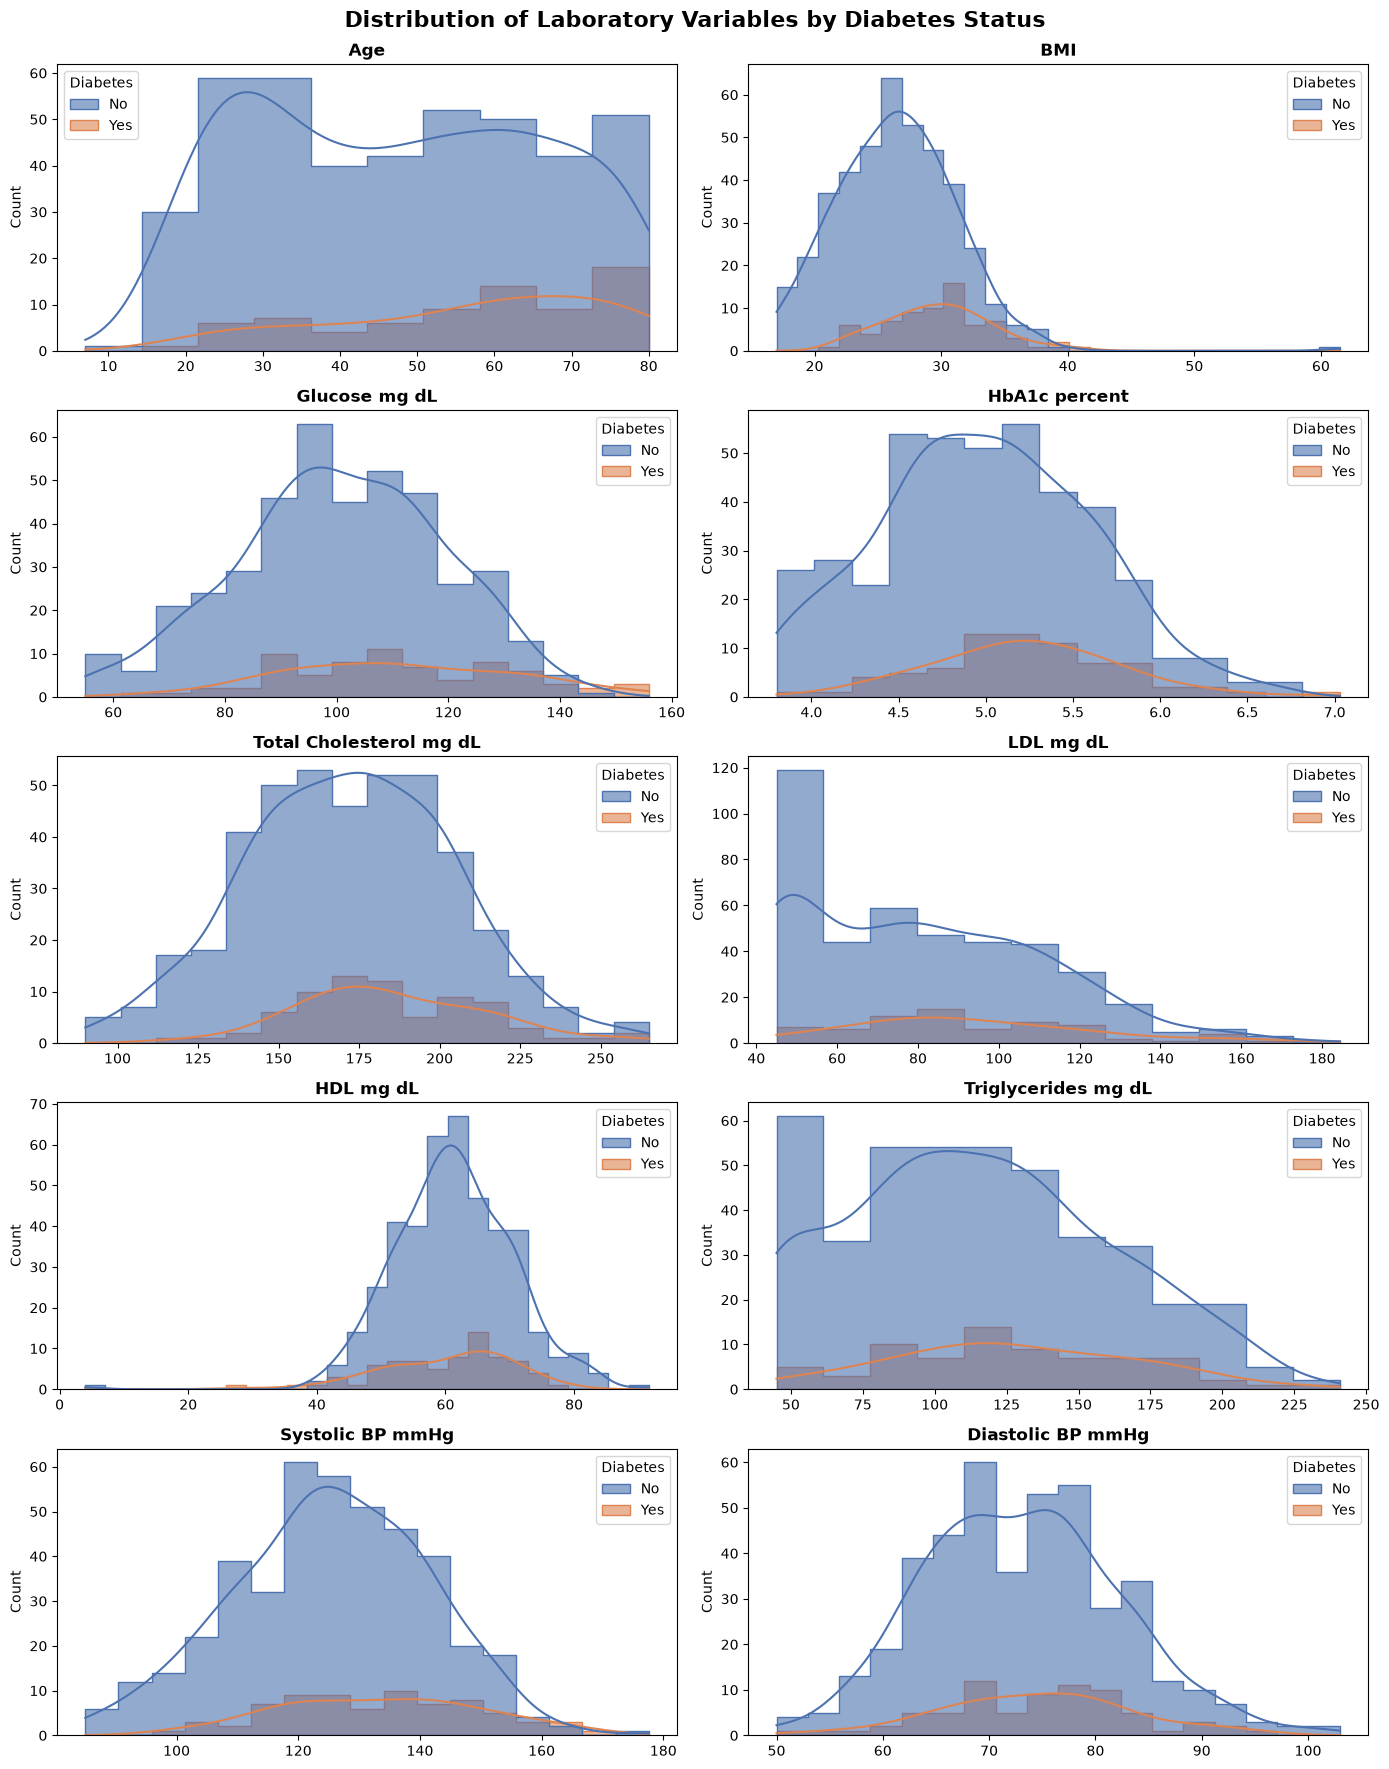

In [23]:
## 6. Exploratory Visualization
## 6.1 Plots for Distribution of Variables by Diabetes Status

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
fig.suptitle('Distribution of Laboratory Variables by Diabetes Status', 
             fontsize=16, fontweight='bold', y=0.98)

axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(
        data=patients_df,
        x=col,
        hue="Diabetes",
        kde=True,
        element="step",
        ax=axes[i],
        palette={'No': '#4C72B0', 'Yes': '#DD8452'},
        alpha=0.6
    )
    
    axes[i].set_title(f'{col.replace("_", " ")}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig('Distribution plots.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
> **📊 Takeaway:** Most laboratory variables show approximately symmetric, unimodal distributions. Glucose and HbA1c show a noticeable right-skew driven by the diabetic subgroup — a clinically expected pattern, since diabetic patients typically have elevated values. The overlap between diabetic and non-diabetic distributions in variables like BMI and Age confirms that these are not deterministic predictors on their own.

C:\Users\Sepideh\AppData\Local\Temp\ipykernel_21860\2651117771.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Sepideh\AppData\Local\Temp\ipykernel_21860\2651117771.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Sepideh\AppData\Local\Temp\ipykernel_21860\2651117771.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Sepideh\AppData\Local\Temp\ipykernel_21860\2651117771.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

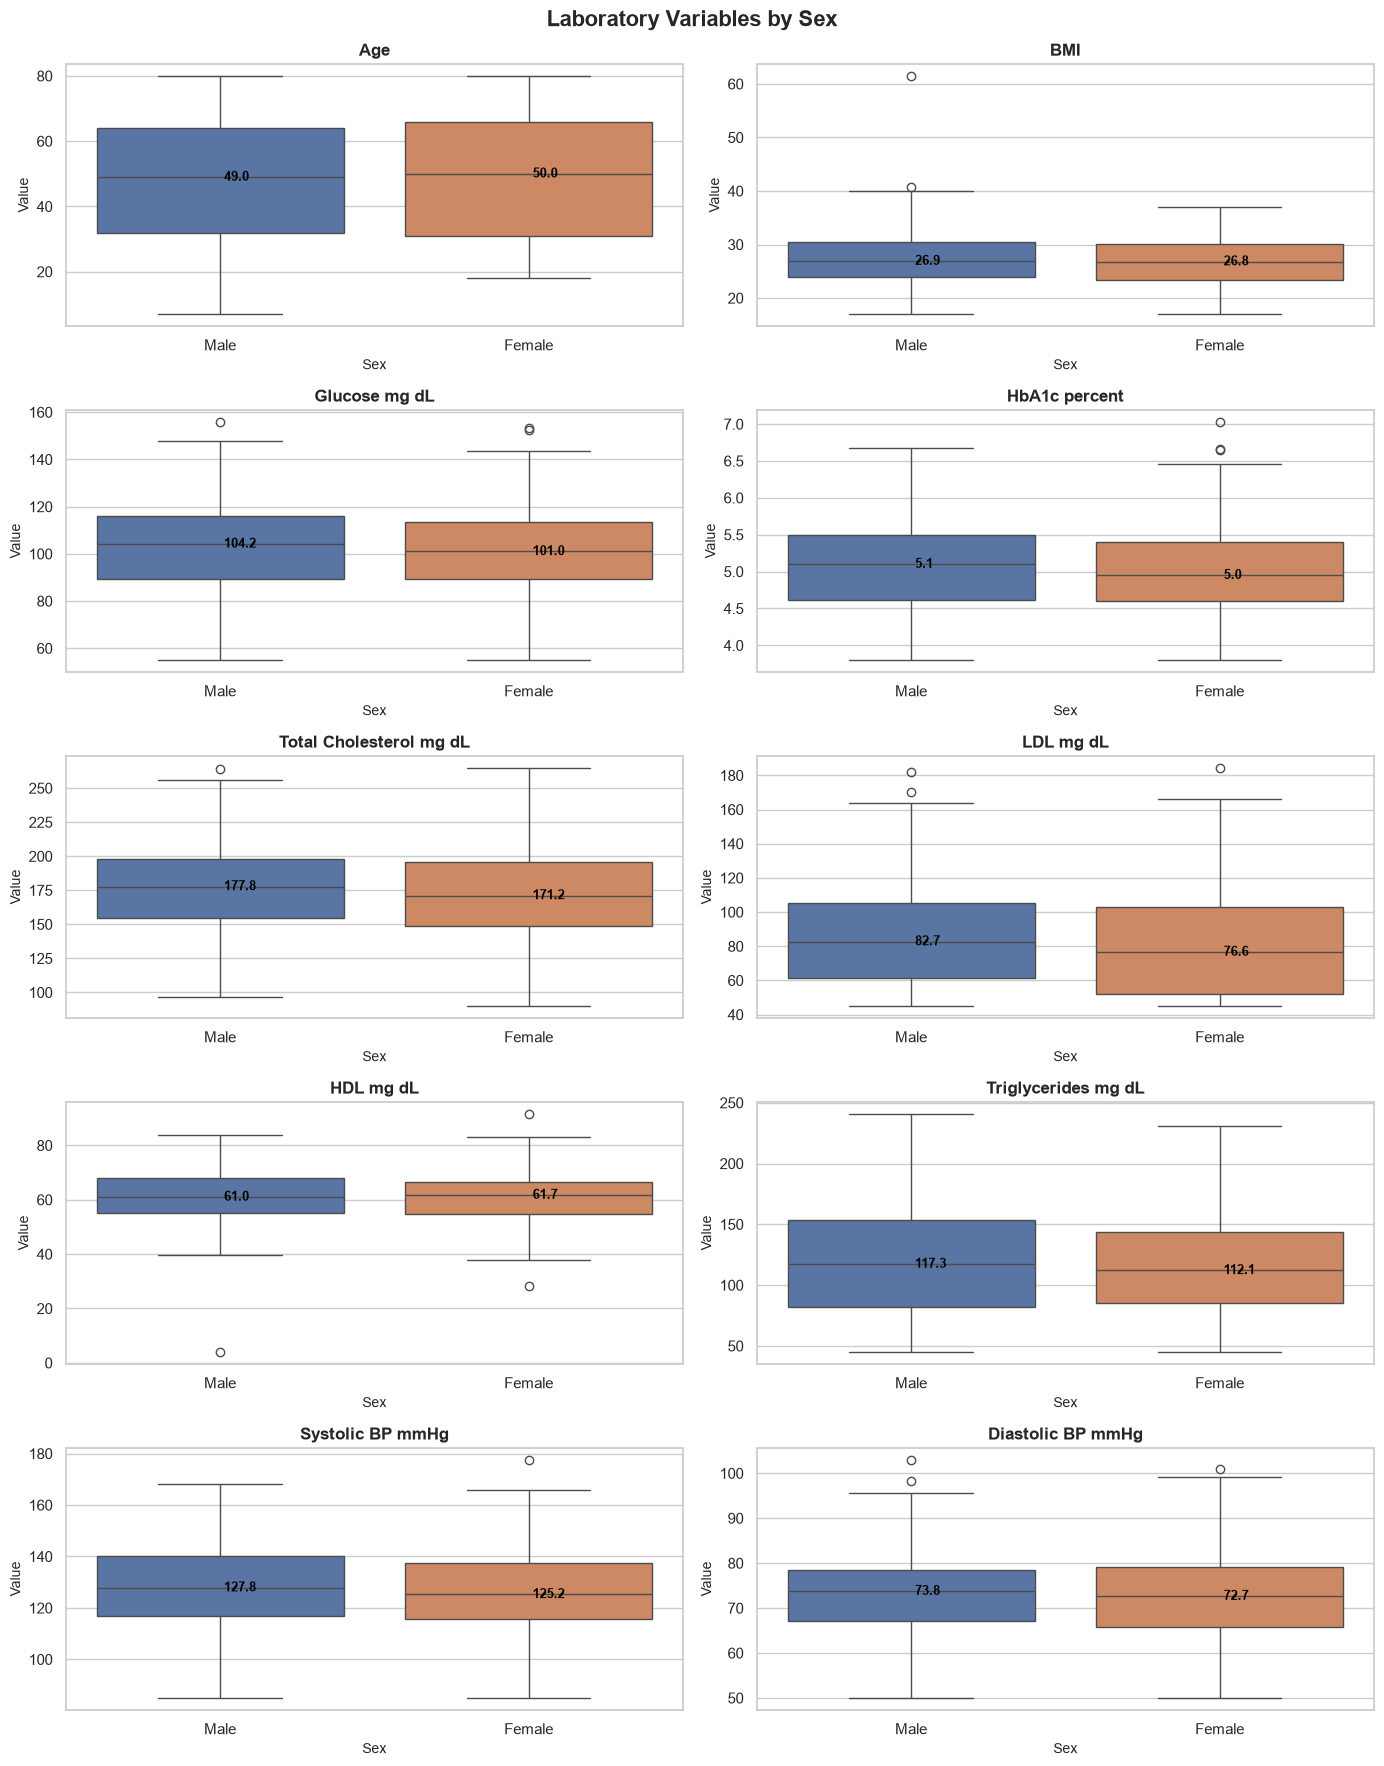

In [24]:
## 6.2 Plots for Comparison of Variables by sex Status

sns.set_theme(style="whitegrid", palette="muted")

vars_to_compare = [
    'Age', 'BMI', 'Glucose_mg_dL', 'HbA1c_percent', 
    'Total_Cholesterol_mg_dL', 'LDL_mg_dL', 'HDL_mg_dL', 
    'Triglycerides_mg_dL', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
fig.suptitle('Laboratory Variables by Sex', fontsize=16, fontweight='bold', y=0.98)

axes = axes.flatten()

for i, var in enumerate(vars_to_compare):
    sns.boxplot(
        data=patients_df, 
        x='Sex', 
        y=var, 
        ax=axes[i],
        palette={'Male': '#4C72B0', 'Female': '#DD8452'}, 
        order=['Male', 'Female']
    )
    
    axes[i].set_title(f'{var.replace("_", " ")}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Sex', fontsize=10)
    axes[i].set_ylabel('Value', fontsize=10)
    
    for j, sex in enumerate(['Male', 'Female']):
        median_val = patients_df[patients_df['Sex'] == sex][var].median()
        axes[i].text(j, median_val, f' {median_val:.1f}', 
                     va='center', ha='left', fontsize=9, color='black', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig('Chart_lab_variable_by_sex.png', dpi=300, bbox_inches='tight')

plt.show()

> **📊 Takeaway:** Biological sex differences align with established clinical patterns: females show higher median HDL ("good cholesterol"), while males show higher median triglycerides and systolic blood pressure. These differences are modest but consistent, suggesting the synthetic data preserves realistic demographic signals.

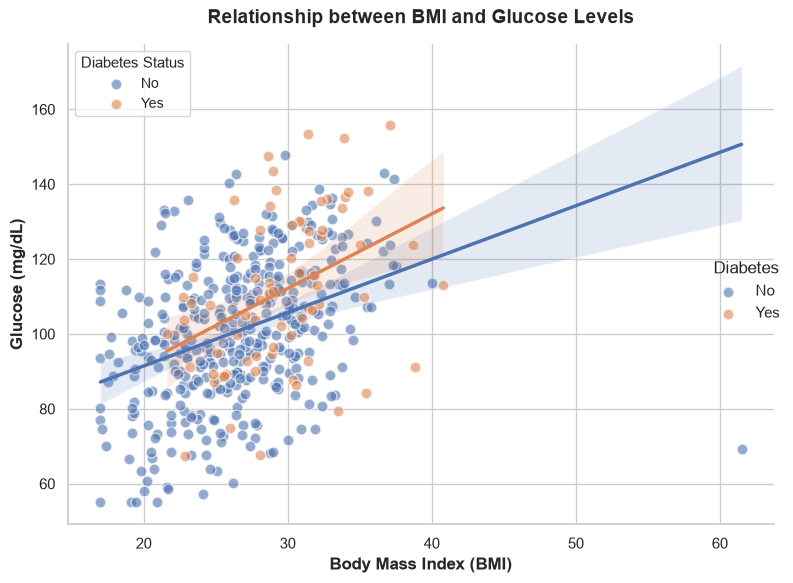

In [25]:
## 6.3 Relationship Between BMI and Glucose

sns.set_theme(style="whitegrid")

g = sns.lmplot(
    data=patients_df,
    x='BMI',
    y='Glucose_mg_dL',
    hue='Diabetes',
    palette={'No': '#4C72B0', 'Yes': '#DD8452'}, 
    scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 60}, 
    line_kws={'linewidth': 2.5},
    height=6,
    aspect=1.2
)

plt.title('Relationship between BMI and Glucose Levels', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Body Mass Index (BMI)', fontsize=12, fontweight='bold')
plt.ylabel('Glucose (mg/dL)', fontsize=12, fontweight='bold')

plt.legend(title='Diabetes Status', title_fontsize='11', fontsize='10', loc='upper left')

plt.tight_layout()
plt.savefig('Chart_BMI_vs_Glucose.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
> **📊 Takeaway:** A positive association between BMI and Glucose is visible, and the trend is visibly steeper among diabetic patients. This aligns with the well-known metabolic relationship between adiposity and insulin resistance, and validates that the synthetic data preserves clinically plausible patterns.

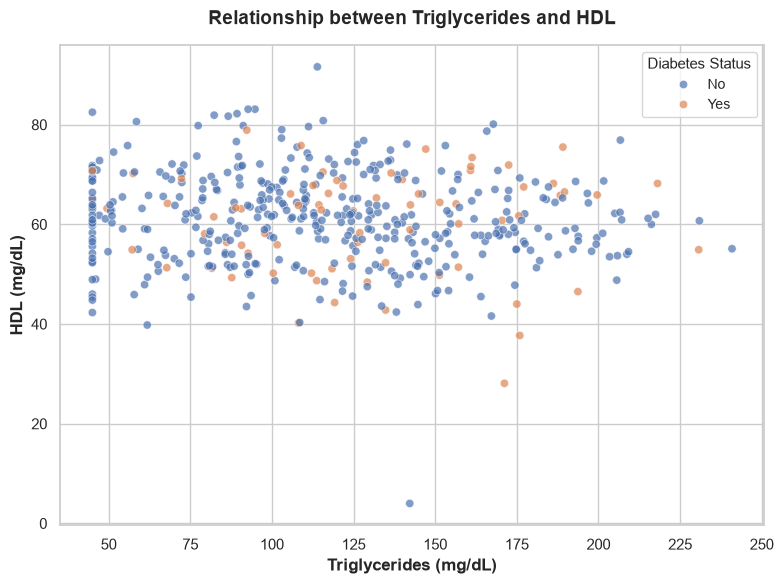

In [26]:
## 6.4 Relationship Between Triglycerides and HDL

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=patients_df, 
    x='Triglycerides_mg_dL', 
    y='HDL_mg_dL', 
    hue='Diabetes',
    palette={'No': '#4C72B0', 'Yes': '#DD8452'},
    alpha=0.7
)
plt.title('Relationship between Triglycerides and HDL', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Triglycerides (mg/dL)', fontsize=12, fontweight='bold')
plt.ylabel('HDL (mg/dL)', fontsize=12, fontweight='bold')
plt.legend(title='Diabetes Status', title_fontsize=11, fontsize=10)
plt.tight_layout()
plt.savefig('Chart_HDL_vs_Tg.png', dpi=300, bbox_inches='tight')

plt.show()

> **📊 Takeaway:** The expected inverse relationship between triglycerides and HDL is clearly visible — a hallmark of metabolic syndrome. Diabetic patients cluster in the high-triglyceride / low-HDL region, reinforcing the biological coherence of the dataset.

In [ ]:
### Why Compute Correlations?

Correlation analysis helps identify pairs of variables that move together. This is critical for two reasons:
1. **Scientific validation** — strong correlations between biologically related variables (e.g., Total Cholesterol and LDL) confirm the data behaves plausibly.
2. **Downstream modeling guidance** — highly correlated predictors (e.g., $r > 0.9$) can cause multicollinearity issues in regression models. The client should be aware before any future modeling work.

In [27]:
## 6.5 Correlation Matrix

correlation_matrix = patients_df[numeric_features].corr()
correlation_matrix = correlation_matrix.round(2)

dfi.export(
    correlation_matrix, 
    'correlation_matrix.png', 
    dpi=300, 
    table_conversion='matplotlib'
)

correlation_matrix

,Age,BMI,Glucose_mg_dL,HbA1c_percent,Total_Cholesterol_mg_dL,LDL_mg_dL,HDL_mg_dL,Triglycerides_mg_dL,Systolic_BP_mmHg,Diastolic_BP_mmHg
Age,1.00,-0.08,0.43,0.16,0.32,0.32,-0.12,0.06,0.49,0.39
BMI,-0.08,1.00,0.40,0.22,0.23,0.27,-0.10,0.26,0.17,0.19
Glucose_mg_dL,0.43,0.40,1.00,0.41,0.30,0.33,-0.18,0.26,0.28,0.27
HbA1c_percent,0.16,0.22,0.41,1.00,0.12,0.15,-0.07,0.16,0.17,0.16
Total_Cholesterol_mg_dL,0.32,0.23,0.30,0.12,1.00,0.92,-0.02,0.08,0.19,0.20
LDL_mg_dL,0.32,0.27,0.33,0.15,0.92,1.00,-0.27,0.12,0.23,0.23
HDL_mg_dL,-0.12,-0.10,-0.18,-0.07,-0.02,-0.27,1.00,-0.10,-0.12,-0.13
Triglycerides_mg_dL,0.06,0.26,0.26,0.16,0.08,0.12,-0.10,1.00,0.15,0.03
Systolic_BP_mmHg,0.49,0.17,0.28,0.17,0.19,0.23,-0.12,0.15,1.00,0.23
Diastolic_BP_mmHg,0.39,0.19,0.27,0.16,0.20,0.23,-0.13,0.03,0.23,1.00


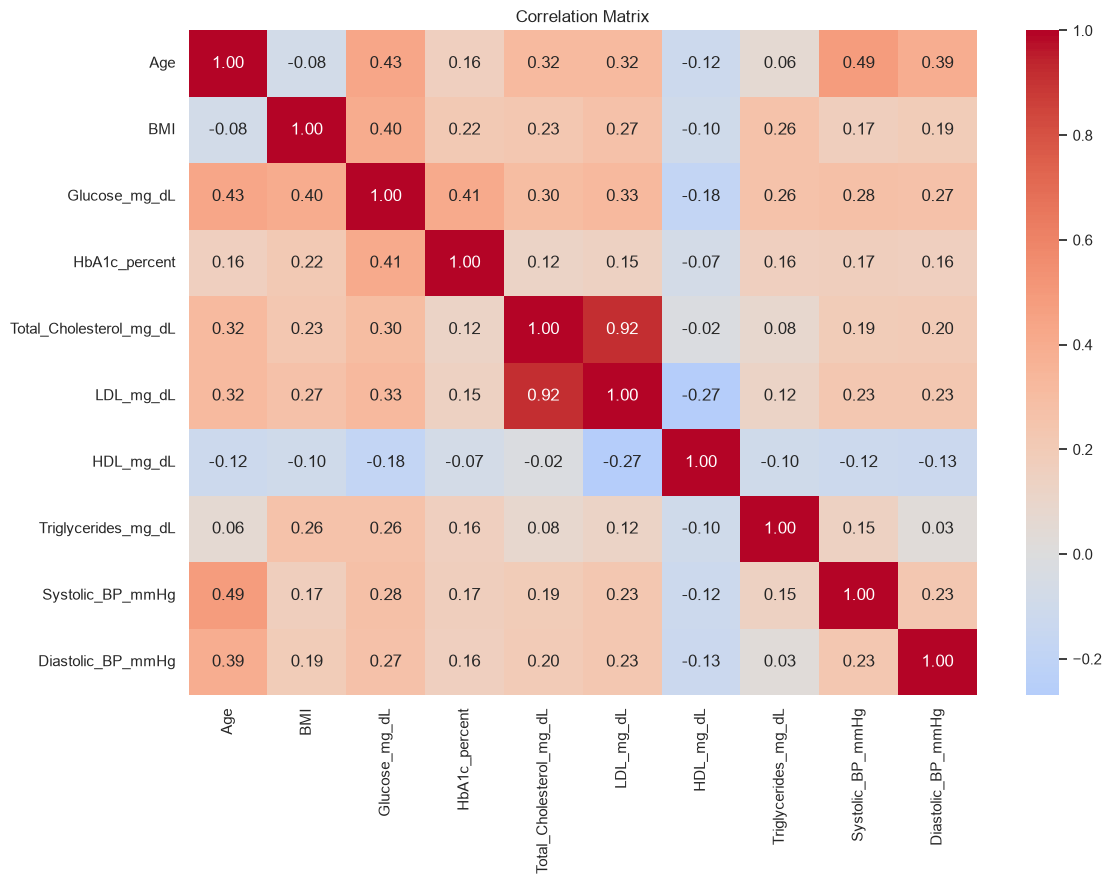

In [28]:
## 6.6 Correlation Heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig('Chart_Correlation_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

> **📊 Takeaway:** The heatmap reveals two key patterns:
> 1. **Biological validation:** Total Cholesterol and LDL are extremely strongly correlated ($r \approx 0.92$), which is expected since LDL is a major component of total cholesterol.
> 2. **Modeling warning:** This same correlation means that any future regression model including both variables would suffer from **multicollinearity**. The client should drop one of them before predictive modeling.

In [29]:
## 6.7 Highly Correlated Variable Pairs

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_correlations = (
    corr_pairs[
        corr_pairs["Correlation"].abs() >= 0.7
    ]
    .sort_values("Correlation", key=abs, ascending=False)
)

high_correlations

,Feature_1,Feature_2,Correlation
45,Total_Cholesterol_mg_dL,LDL_mg_dL,0.92


In [30]:
## 6.8 Export the Cleaned Dataset

patients_df.to_excel("laboratory_patient_data_cleaned.xlsx", index=False)
print("✅ Cleaned dataset successfully exported to 'laboratory_patient_data_cleaned.xlsx'")

✅ Cleaned dataset successfully exported to 'laboratory_patient_data_cleaned.xlsx'


In [ ]:
## 7. Findings & Conclusions <a id="7-findings"></a>

### 🔍 Data Quality Summary
- **503 → 500 records** after removing 3 exact duplicates.
- **57 missing values** across 6 numeric variables; no single variable exceeds 2.5% missingness — a manageable level.
- **Categorical `Sex` column** standardized from 5 variants to 2 (`Male` / `Female`).
- **Implausible values flagged** (e.g., Age = 7, Total Cholesterol < 100 mg/dL) — these require domain-expert review before the dataset enters production pipelines.

### 📊 Key Descriptive Patterns
- The cohort is **balanced by sex** (~50/50) with a **median age of ~50 years**.
- **Diabetes prevalence is ~15%**, consistent with an adult outpatient population.
- Median BMI (~26.8) falls in the **overweight** range — a realistic population baseline.

### 🔗 Notable Relationships
1. **Total Cholesterol ↔ LDL** ($r \approx 0.92$): extremely strong — expected, since LDL is a major component of total cholesterol. *Consider dropping one in any downstream regression to avoid multicollinearity.*
2. **BMI ↔ Glucose**: positive association, visibly stronger among diabetic patients.
3. **Triglycerides ↔ HDL**: inverse relationship, consistent with the metabolic syndrome pattern.
4. **Sex differences**: Females show higher median HDL; males show higher median triglycerides and systolic BP — patterns that match established clinical literature.

### 🚀 Recommendations for the Client
1. **Have a pathologist review the flagged implausible values** before the dataset enters production pipelines.
2. **Investigate the missingness mechanism** — if missing BMI values are concentrated in a specific subgroup, simple median imputation may introduce bias.
3. **For any downstream modeling**, drop either `Total_Cholesterol` or `LDL` to avoid multicollinearity.
4. **Collect fasting status** in future recordings — triglycerides and glucose are highly fasting-dependent.
5. **Consider enriching the dataset** with lifestyle variables (smoking, physical activity, medication use) to enable more nuanced analyses.

In [ ]:
## 8. Limitations <a id="8-limitations"></a>

This analysis is informative but bounded by several important constraints:

1. **Synthetic data**: The dataset is AI-generated for portfolio purposes. While it mimics realistic data-quality issues, it does not represent real patient outcomes.
2. **No causal claims**: Correlations observed here (e.g., BMI ↔ Glucose) do not imply causation. Only controlled studies can establish causal relationships.
3. **Missing clinical context**: Fasting status, medication use, family history, and lifestyle factors are absent — all of which materially affect lab interpretation.
4. **Unknown missingness mechanism**: If data is *not* Missing Completely at Random (MCAR), descriptive statistics may carry subtle bias.
5. **Small sample size**: With only 500 records and ~75 diabetic cases, estimates for the diabetic subgroup have wider confidence intervals.
6. **No predictive modeling**: Per the project brief, this analysis is strictly exploratory. Any future predictive work would require additional validation, feature engineering, and external test data.